In [1]:
!pip install pandas matplotlib seaborn jupyter

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

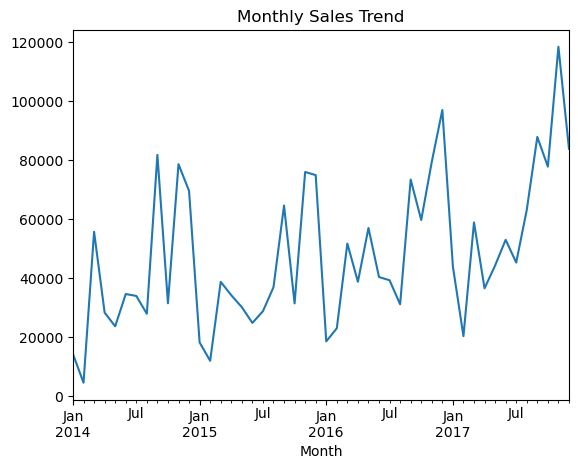

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Superstore.csv", encoding="latin1")

# View data
df.head()

# Basic info
df.info()

# Check null values
df.isnull().sum()

#DATA CLEANING
# Remove duplicates
df = df.drop_duplicates()

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create new features
df['Month'] = df['Order Date'].dt.to_period('M')
df['Year'] = df['Order Date'].dt.year

df.head()

#monthly sales 
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()


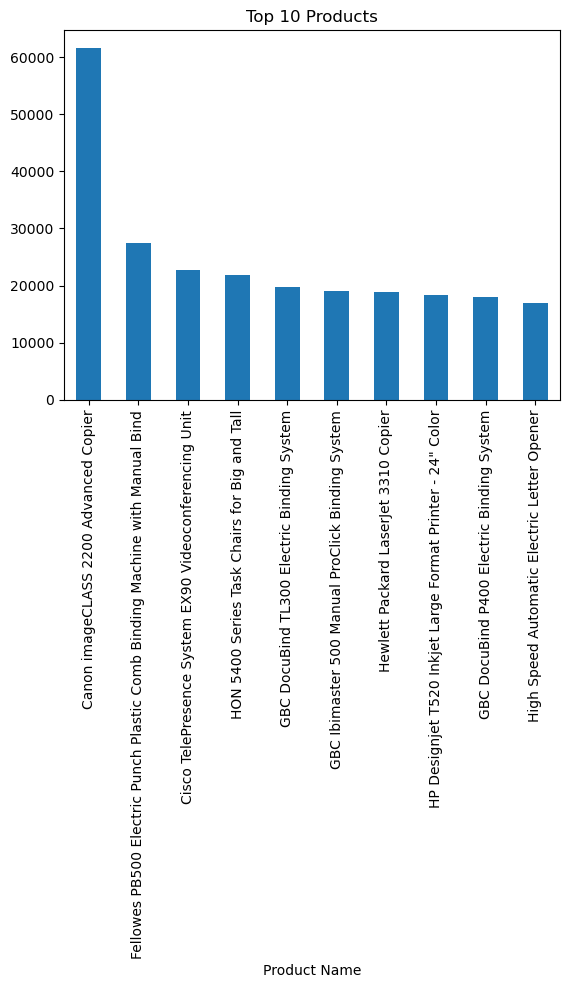

In [17]:
#top products 
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

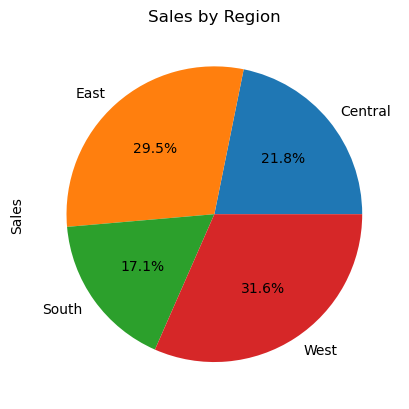

In [18]:
#region wise sales 
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Region")
plt.show()

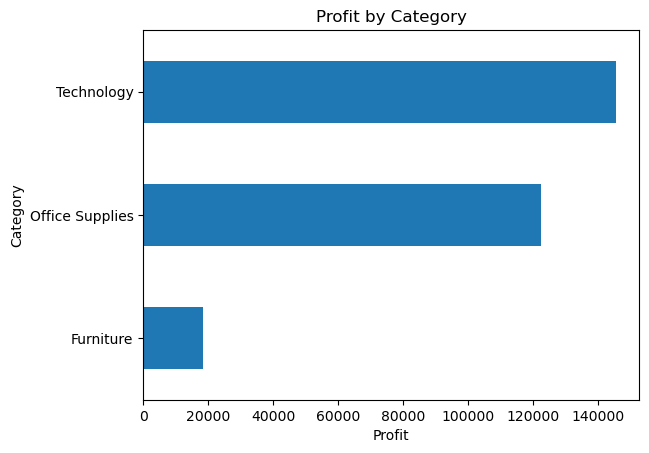

In [19]:
# Profit by Category
profit_category = df.groupby('Category')['Profit'].sum().sort_values()

profit_category.plot(kind='barh')
plt.title("Profit by Category")
plt.xlabel("Profit")
plt.show()

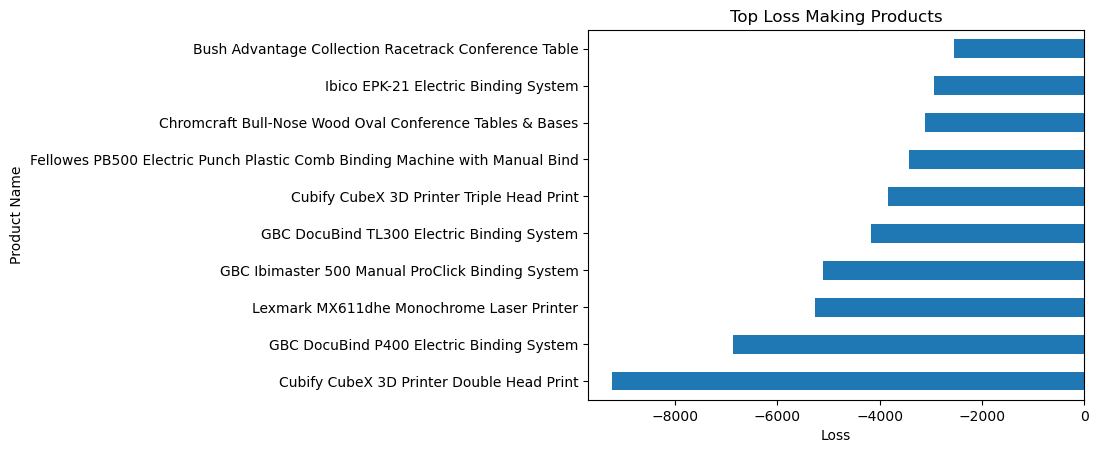

In [20]:
# Products with losses
loss_products = df[df['Profit'] < 0]

top_loss = loss_products.groupby('Product Name')['Profit'].sum().sort_values().head(10)

top_loss.plot(kind='barh')
plt.title("Top Loss Making Products")
plt.xlabel("Loss")
plt.show()

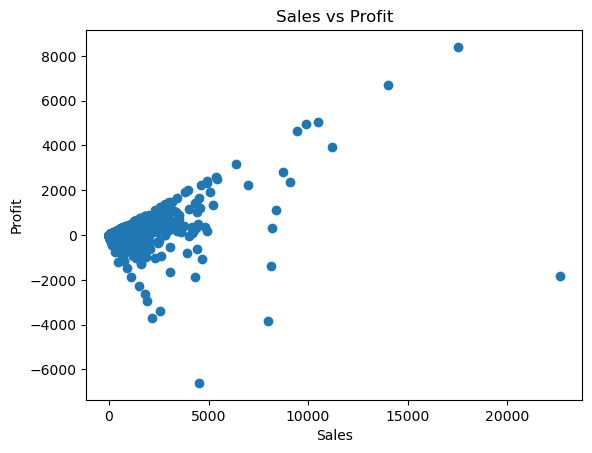

In [21]:
#sales vs profit B ins
plt.scatter(df['Sales'], df['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

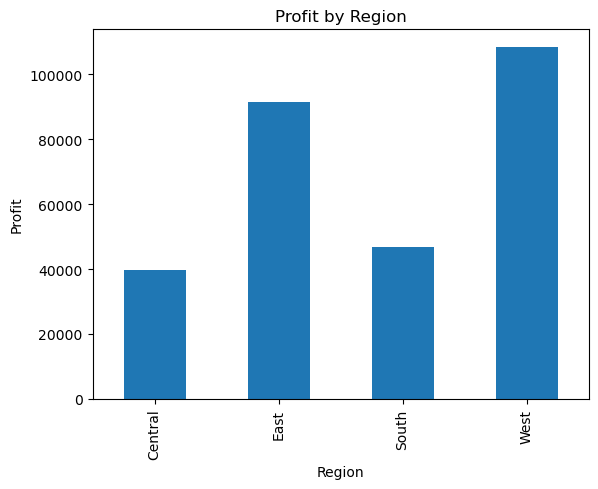

In [22]:
#region wise profit
profit_region = df.groupby('Region')['Profit'].sum()

profit_region.plot(kind='bar')
plt.title("Profit by Region")
plt.ylabel("Profit")
plt.show()


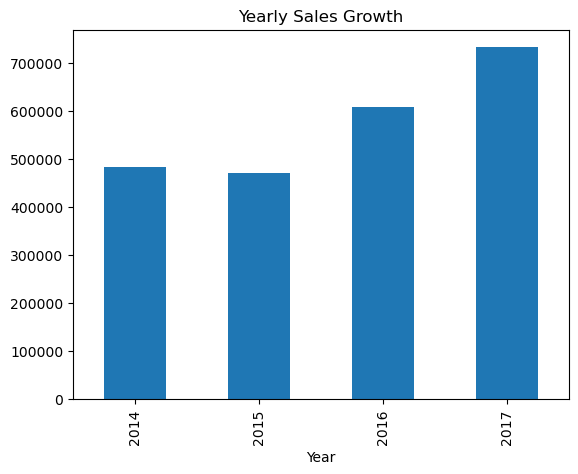

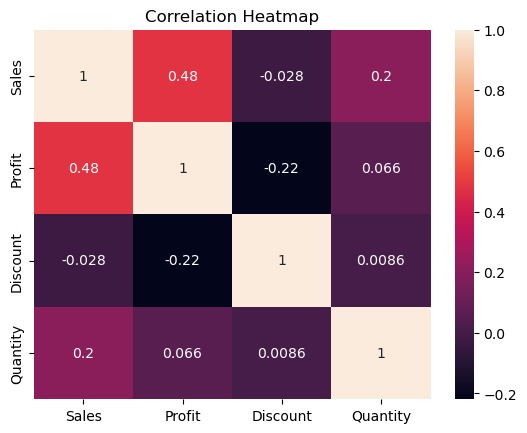

In [26]:
#year wise growth 
yearly_sales = df.groupby('Year')['Sales'].sum()

yearly_sales.plot(kind='bar')
plt.title("Yearly Sales Growth")
plt.show()

#correlation heat map
sns.heatmap(df[['Sales','Profit','Discount','Quantity']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

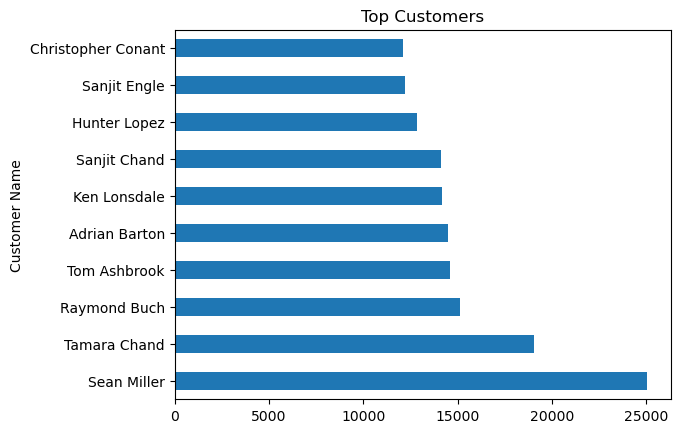

In [24]:
# Top customers
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='barh')
plt.title("Top Customers")
plt.show()